**CNN Model**

Step 1: Setup Google Colab and Import Libraries

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import mnist
from google.colab import files
from PIL import Image


Step 2: Load and Preprocess Dataset

In [ ]:
# Load MNIST dataset using Keras
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshape and normalize the images
train_images = train_images.reshape(-1, 28, 28, 1) / 255.0
test_images = test_images.reshape(-1, 28, 28, 1) / 255.0

# Now you can use train_images, train_labels, test_images, and test_labels

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


 Step 3: Build a Neural Network Model

In [ ]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes (digits 0-9)
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Step 4: Train the Model

In [ ]:
model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9085 - loss: 0.2966 - val_accuracy: 0.9854 - val_loss: 0.0463
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9852 - loss: 0.0472 - val_accuracy: 0.9924 - val_loss: 0.0254
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9911 - loss: 0.0275 - val_accuracy: 0.9889 - val_loss: 0.0336
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9932 - loss: 0.0199 - val_accuracy: 0.9924 - val_loss: 0.0253
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 34ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9904 - val_loss: 0.0302


 Step 5: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9883 - loss: 0.0388
Test Accuracy: 99.04%


Saving digit4.png to digit4.png


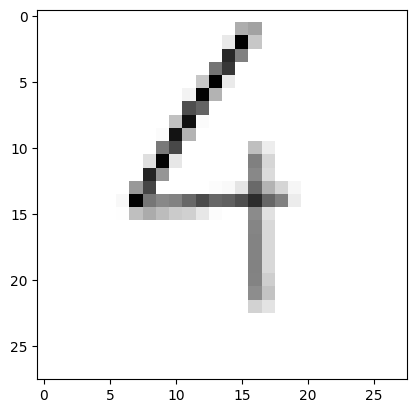

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted Digit: 4


In [ ]:
uploaded = files.upload()
for filename in uploaded.keys():
    img = Image.open(filename).convert("L")  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to 28x28
    img = np.array(img) / 255.0  # Normalize
    img = img.reshape(1, 28, 28, 1)  # Reshape for model

    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.show()

    prediction = model.predict(img)
    predicted_digit = np.argmax(prediction)
    print(f"Predicted Digit: {predicted_digit}")

Finish here!!

Now more training model , code strting from here !


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import mnist
from google.colab import files
from PIL import Image


In [ ]:
# Load MNIST dataset using Keras
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshape and normalize the images
train_images = train_images.reshape(-1, 28, 28, 1) / 255.0
test_images = test_images.reshape(-1, 28, 28, 1) / 255.0

print(f"Training samples: {train_images.shape[0]}, Test samples: {test_images.shape[0]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000, Test samples: 10000


In [ ]:
# Define the CNN Model
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # Output layer for 10 digit classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.9096 - loss: 0.2930 - val_accuracy: 0.9837 - val_loss: 0.0485
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 31ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9894 - val_loss: 0.0309
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9911 - loss: 0.0274 - val_accuracy: 0.9911 - val_loss: 0.0266
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 30ms/step - accuracy: 0.9936 - loss: 0.0195 - val_accuracy: 0.9909 - val_loss: 0.0267
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 31ms/step - accuracy: 0.9956 - loss: 0.0139 - val_accuracy: 0.9886 - val_loss: 0.0349


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9883 - loss: 0.0388
Test Accuracy: 99.04%


In [ ]:
model.save("handwritten_digit_model.keras")


Saving digit4.jpg to digit4.jpg


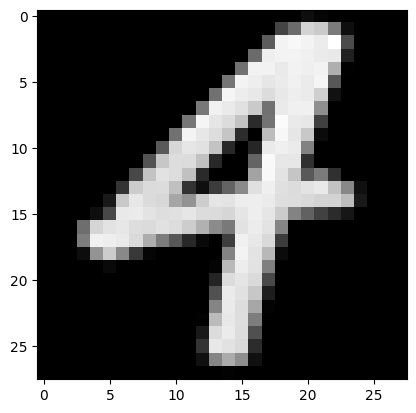

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Digit: 4


In [ ]:
import tensorflow as tf # Import TensorFlow library

# Load the trained model
model = tf.keras.models.load_model("handwritten_digit_model.keras")

def preprocess_image(filename):
    img = Image.open(filename).convert("L")  # Convert to grayscale
    img = img.resize((28, 28))  # Resize to 28x28
    img = np.array(img) / 255.0  # Normalize
    img = img.reshape(1, 28, 28, 1)  # Reshape for model
    return img

# User uploads image
uploaded = files.upload()
for filename in uploaded.keys():
    img = preprocess_image(filename)

    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.show()

    prediction = model.predict(img)
    predicted_digit = np.argmax(prediction)
    print(f"Predicted Digit: {predicted_digit}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


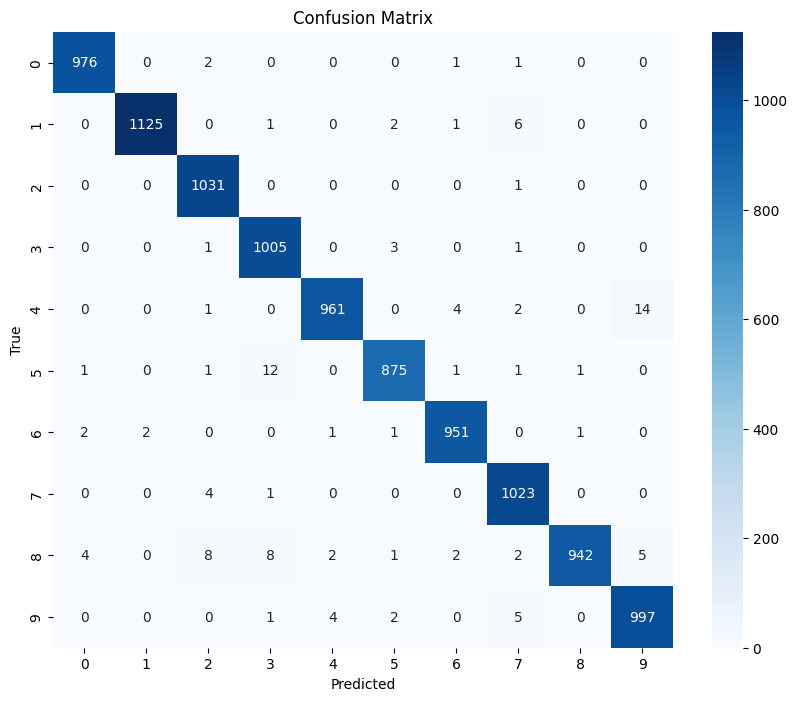

Class 0:
  Precision: 99.29%
  Recall: 99.59%
  F1-Score: 99.44%
Class 1:
  Precision: 99.82%
  Recall: 99.12%
  F1-Score: 99.47%
Class 2:
  Precision: 98.38%
  Recall: 99.90%
  F1-Score: 99.13%
Class 3:
  Precision: 97.76%
  Recall: 99.50%
  F1-Score: 98.63%
Class 4:
  Precision: 99.28%
  Recall: 97.86%
  F1-Score: 98.56%
Class 5:
  Precision: 98.98%
  Recall: 98.09%
  F1-Score: 98.54%
Class 6:
  Precision: 99.06%
  Recall: 99.27%
  F1-Score: 99.17%
Class 7:
  Precision: 98.18%
  Recall: 99.51%
  F1-Score: 98.84%
Class 8:
  Precision: 99.79%
  Recall: 96.71%
  F1-Score: 98.23%
Class 9:
  Precision: 98.13%
  Recall: 98.81%
  F1-Score: 98.47%
Accuracy: 98.86%
Macro avg:
  Precision: 98.87%
  Recall: 98.84%
  F1-Score: 98.85%
Weighted avg:
  Precision: 98.87%
  Recall: 98.86%
  F1-Score: 98.86%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Generate predictions
y_pred = model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class predictions
y_true = test_labels  # True labels

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=[str(i) for i in range(10)], output_dict=True)

# Extract precision, recall, F1, and accuracy in percentages
for key in report:
    if key == 'accuracy':
        print(f"Accuracy: {report[key] * 100:.2f}%")
    elif key in ['macro avg', 'weighted avg']:
        print(f"{key.capitalize()}:")
        print(f"  Precision: {report[key]['precision'] * 100:.2f}%")
        print(f"  Recall: {report[key]['recall'] * 100:.2f}%")
        print(f"  F1-Score: {report[key]['f1-score'] * 100:.2f}%")
    else:  # For individual classes (0-9)
        print(f"Class {key}:")
        print(f"  Precision: {report[key]['precision'] * 100:.2f}%")
        print(f"  Recall: {report[key]['recall'] * 100:.2f}%")
        print(f"  F1-Score: {report[key]['f1-score'] * 100:.2f}%")
